Loading data...
Input Shape: (5069, 96, 7) (Samples, Lookback, Features)
Output Shape: (5069, 96, 2) (Samples, Horizon, Targets)
Starting Training...
Epoch 10/50 | Train Loss: 0.03016 | Val Loss: 0.02926
Epoch 20/50 | Train Loss: 0.02819 | Val Loss: 0.02887
Epoch 30/50 | Train Loss: 0.02727 | Val Loss: 0.03000
Epoch 40/50 | Train Loss: 0.02506 | Val Loss: 0.03100
Epoch 50/50 | Train Loss: 0.02418 | Val Loss: 0.03155
Overall RMSE: 0.1776


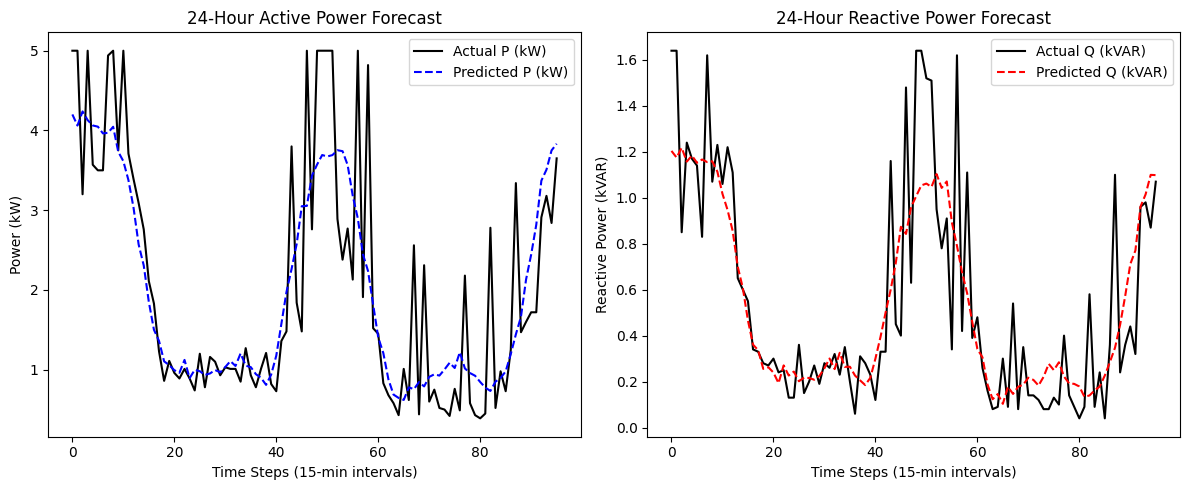

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------------------------
# CONFIGURATION
# ---------------------------
class Config:
    CSV_FILE = 'microgrid_data.csv'   # Your source CSV
    # Inputs must include P, Q, V, I, cos_phi
    FEATURE_COLS = ['P', 'Q', 'V', 'I', 'PF']
    TARGET_COLS = ['P', 'Q']          # We only predict P and Q for the optimizer

    # 24 hours of history @ 15 min intervals
    LOOKBACK = 96
    # Predict next 24 hours (96 steps) for "Look-Ahead" optimization
    FORECAST_HORIZON = 96

    TRAIN_SPLIT = 0.6
    BATCH_SIZE = 32
    HIDDEN_SIZE = 64
    NUM_LAYERS = 4                    # Stacked LSTM layers
    EPOCHS = 50
    LR = 0.001
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config = Config()

# ---------------------------
# 1. Feature Engineering & Preprocessing
# ---------------------------
def add_cyclical_time_features(df):
    """
    "Hard Part: Cyclic Time Encoding."
    Maps hour/minute to Sine/Cosine so the model knows 23:59 is close to 00:00.
    """
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Seconds in day
    seconds_in_day = 24 * 60 * 60
    df['seconds'] = df['timestamp'].dt.hour * 3600 + df['timestamp'].dt.minute * 60

    # Sin/Cos encoding
    df['sin_time'] = np.sin(2 * np.pi * df['seconds'] / seconds_in_day)
    df['cos_time'] = np.cos(2 * np.pi * df['seconds'] / seconds_in_day)

    return df

# ---------------------------
# 2. Dataset Class (Sliding Window)
# ---------------------------
class MicrogridDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def create_multistep_sequences(input_data, target_data, lookback, horizon):
    """
    Reshapes data into 3D Tensor (samples, time_steps, features).
    Creates X (past window) and y (future sequence).
    """
    X, y = [], []
    # We need enough data for lookback + horizon
    for i in range(len(input_data) - lookback - horizon + 1):
        # Input: All features (P, Q, V, I, PF, time...)
        X.append(input_data[i : i + lookback])
        # Output: Only Target features (P, Q) for the next 'horizon' steps
        y.append(target_data[i + lookback : i + lookback + horizon])

    return np.array(X), np.array(y)

# ---------------------------
# 3. LSTM Model (Seq2Seq Architecture)
# ---------------------------
class MultiStepLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, horizon):
        super(MultiStepLSTM, self).__init__()
        self.horizon = horizon
        self.output_size = output_size

        # Stacked LSTM Layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)

        # Output layer maps hidden state to flattened output (horizon * targets)
        self.fc = nn.Linear(hidden_size, horizon * output_size)

    def forward(self, x):
        # LSTM processes the input sequence
        # out shape: (batch, lookback, hidden_size)
        lstm_out, _ = self.lstm(x)

        # Take the last time step's hidden state
        last_step = lstm_out[:, -1, :]

        # Predict all future steps at once
        prediction = self.fc(last_step)

        # Reshape to (batch, 96 steps, 2 features)
        prediction = prediction.view(-1, self.horizon, self.output_size)
        return prediction

# ---------------------------
# 4. Training Pipeline
# ---------------------------
def train_model():
    # --- A. Data Loading ---
    print("Loading data...")
    # NOTE: Assuming CSV has columns: timestamp, P, Q, V, I, PF
    df = pd.read_csv(config.CSV_FILE)

    # Apply Engineering: Cyclical Time
    df = add_cyclical_time_features(df)

    # Define Input columns (Electrical + Time)
    input_cols = config.FEATURE_COLS + ['sin_time', 'cos_time']
    target_cols = config.TARGET_COLS

    # --- B. Normalization ---
    # We use separate scalers for input and target to make inverse transform easier
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))

    data_X_scaled = scaler_X.fit_transform(df[input_cols])
    data_y_scaled = scaler_y.fit_transform(df[target_cols])

    # --- C. Sequence Generation ---
    X, y = create_multistep_sequences(
        data_X_scaled,
        data_y_scaled,
        config.LOOKBACK,
        config.FORECAST_HORIZON
    )

    # Train/Val Split
    split_idx = int(len(X) * config.TRAIN_SPLIT)
    X_train, X_val = X[:split_idx], X[split_idx:]
    y_train, y_val = y[:split_idx], y[split_idx:]

    train_loader = DataLoader(MicrogridDataset(X_train, y_train),
                              batch_size=config.BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(MicrogridDataset(X_val, y_val),
                            batch_size=config.BATCH_SIZE, shuffle=False)

    print(f"Input Shape: {X_train.shape} (Samples, Lookback, Features)")
    print(f"Output Shape: {y_train.shape} (Samples, Horizon, Targets)")

    # --- D. Model Initialization ---
    model = MultiStepLSTM(
        input_size=X_train.shape[2],  # ~7 features
        hidden_size=config.HIDDEN_SIZE,
        num_layers=config.NUM_LAYERS,
        output_size=len(config.TARGET_COLS), # 2 (P, Q)
        horizon=config.FORECAST_HORIZON
    ).to(config.DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=config.LR)
    criterion = nn.MSELoss() # Can swap for Pinball loss later for quantiles

    # --- E. Training Loop ---
    print("Starting Training...")
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(config.EPOCHS):
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(config.DEVICE), batch_y.to(config.DEVICE)

            optimizer.zero_grad()
            preds = model(batch_X)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(config.DEVICE), batch_y.to(config.DEVICE)
                preds = model(batch_X)
                val_loss += criterion(preds, batch_y).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{config.EPOCHS} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")

    # Save artifacts
    torch.save(model, 'lstm_microgrid_model.pth')
    return model, scaler_y, val_loader

# ---------------------------
# 5. Validation & Plotting
# ---------------------------
def evaluate_model(model, val_loader, scaler_y):
    model.eval()
    all_preds = []
    all_actuals = []

    # Generate predictions
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(config.DEVICE)
            preds = model(batch_X) # Shape: (batch, 96, 2)
            all_preds.append(preds.cpu().numpy())
            all_actuals.append(batch_y.numpy())

    # Concatenate all batches
    all_preds = np.concatenate(all_preds, axis=0)
    all_actuals = np.concatenate(all_actuals, axis=0)

    # Calculate Metrics for the WHOLE horizon
    # We flatten to calculate aggregate RMSE
    mse = mean_squared_error(all_actuals.reshape(-1, 2), all_preds.reshape(-1, 2))
    print(f"Overall RMSE: {np.sqrt(mse):.4f}")

    # --- Plotting one specific sample sequence ---
    # Let's look at the first sample in the validation set
    sample_idx = 0

    # Inverse transform to get real kW / kVAR
    pred_sample = scaler_y.inverse_transform(all_preds[sample_idx])
    actual_sample = scaler_y.inverse_transform(all_actuals[sample_idx])

    plt.figure(figsize=(12, 5))

    # Plot Active Power (P)
    plt.subplot(1, 2, 1)
    plt.plot(actual_sample[:, 0], label='Actual P (kW)', color='black')
    plt.plot(pred_sample[:, 0], label='Predicted P (kW)', color='blue', linestyle='--')
    plt.title(f"24-Hour Active Power Forecast")
    plt.xlabel("Time Steps (15-min intervals)")
    plt.ylabel("Power (kW)")
    plt.legend()

    # Plot Reactive Power (Q)
    plt.subplot(1, 2, 2)
    plt.plot(actual_sample[:, 1], label='Actual Q (kVAR)', color='black')
    plt.plot(pred_sample[:, 1], label='Predicted Q (kVAR)', color='red', linestyle='--')
    plt.title(f"24-Hour Reactive Power Forecast")
    plt.xlabel("Time Steps (15-min intervals)")
    plt.ylabel("Reactive Power (kVAR)")
    plt.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Create dummy data if CSV doesn't exist to test the logic
    try:
        model, scaler_y, val_loader = train_model()
        evaluate_model(model, val_loader, scaler_y)
    except FileNotFoundError:
        print("Error: 'microgrid_data.csv' not found. Please ensure the CSV exists with columns: timestamp, P, Q, V, I, PF")